Hardware overlay inladen...

--- Verwerken van Motor 1/10 ---
-> Hardware Convolutie succesvol in: 1.023 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_1.png


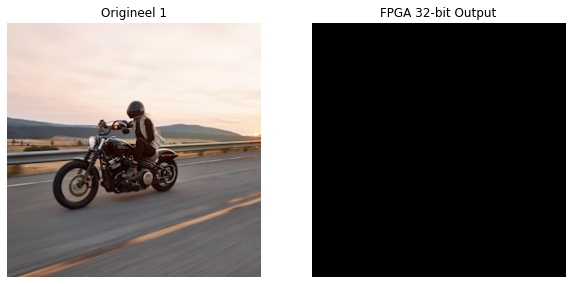


--- Verwerken van Motor 2/10 ---
-> Hardware Convolutie succesvol in: 1.029 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_2.png


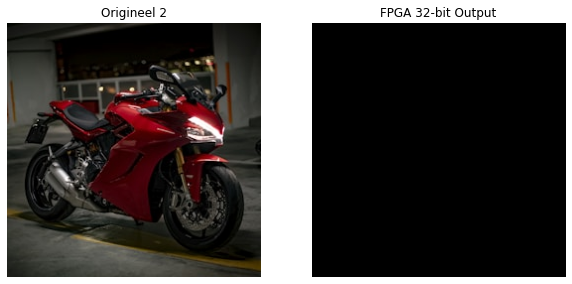


--- Verwerken van Motor 3/10 ---
-> Hardware Convolutie succesvol in: 1.060 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_3.png


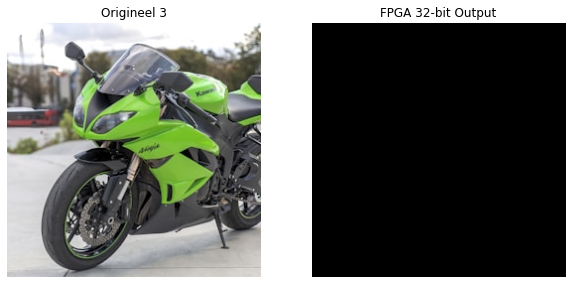


--- Verwerken van Motor 4/10 ---
-> Hardware Convolutie succesvol in: 1.036 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_4.png


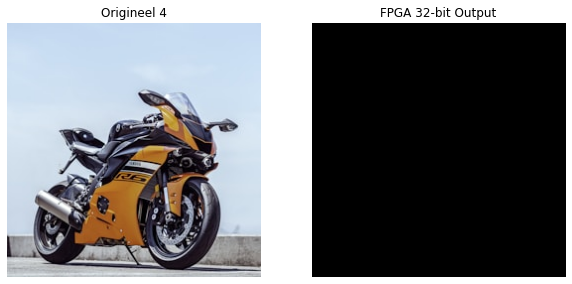


--- Verwerken van Motor 5/10 ---
-> Hardware Convolutie succesvol in: 1.074 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_5.png


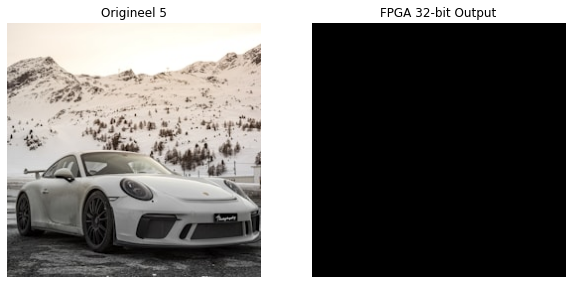


--- Verwerken van Motor 6/10 ---
-> Hardware Convolutie succesvol in: 1.166 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_6.png


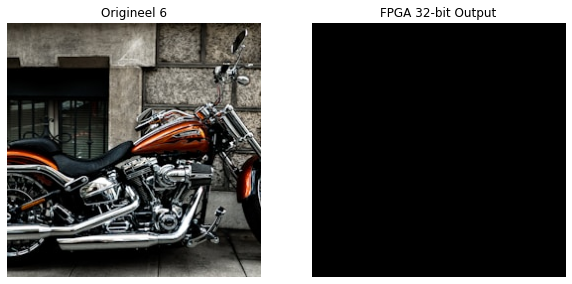


--- Verwerken van Motor 7/10 ---
-> Hardware Convolutie succesvol in: 1.079 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_7.png


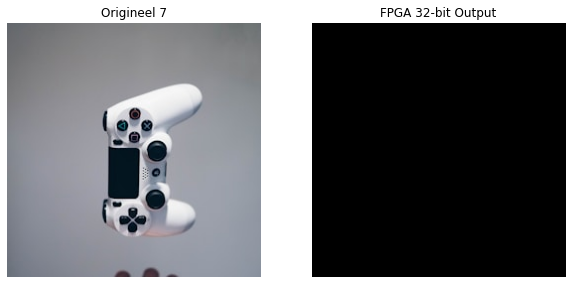


--- Verwerken van Motor 8/10 ---
Fout bij verwerken van URL 8: cannot identify image file <_io.BytesIO object at 0xabee3618>

--- Verwerken van Motor 9/10 ---
-> Hardware Convolutie succesvol in: 1.075 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_9.png


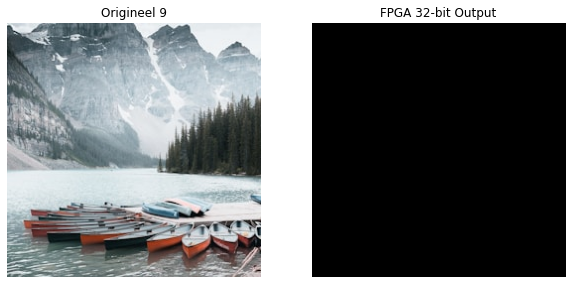


--- Verwerken van Motor 10/10 ---
-> Hardware Convolutie succesvol in: 1.182 ms
-> Afbeelding succesvol opgeslagen als: ./motor_output_10.png


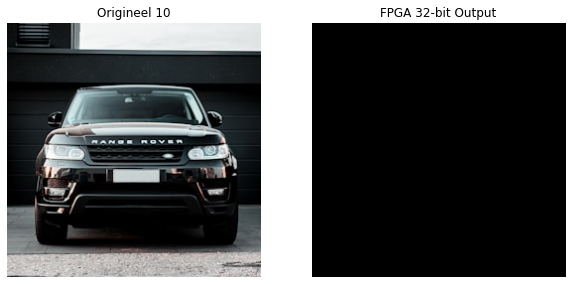


Alle afbeeldingen zijn opeenvolgend verwerkt en de buffers zijn opgeruimd!


In [2]:
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from pynq import Overlay
from pynq import allocate
import time
import os

# ==========================================
# 1. HARDWARE INLADEN (OVERLAY)
# ==========================================
print("Hardware overlay inladen...")
# Let op: Zorg dat je .bit en .hwh bestand exact dezelfde naam hebben in deze map!
overlay = Overlay("./2D_Convolutie.bit")
hls_ip = overlay.filter_afbeelding_0

# ==========================================
# 2. CONFIGURATIE & URLS
# ==========================================
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

motor_urls = [
    "https://images.unsplash.com/photo-1558981806-ec527fa84c39?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1568772585407-9361f9bf3a87?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1599819811279-d5ad9cccf838?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1609630875171-b1321377ee65?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1614162692292-7ac56d7f7f1e?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1515777315835-281b94c9589f?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1509198397868-475647b2a1e5?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1449495940866-3a72f91e4210?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1532581291347-9c39cf10a73c?auto=format&ar=1:1&fit=crop&w=256&h=256",
    "https://images.unsplash.com/photo-1563720223185-11003d516935?auto=format&ar=1:1&fit=crop&w=256&h=256"
]

IMG_SIZE = 256  
CHANNELS = 3    
totale_pixels = IMG_SIZE * IMG_SIZE  # Aantal 32-bit 'words'

# ==========================================
# 3. GEOPTIMALISEERDE BUFFER ALLOCATIE (32-bit)
# ==========================================
# We alloceren nu dtype=np.uint32. Dit matcht exact met de ap_uint<32> aan de hardwarekant!
invoer_buffer  = allocate(shape=(totale_pixels,), dtype=np.uint32)
uitvoer_buffer = allocate(shape=(totale_pixels,), dtype=np.uint32)

# ==========================================
# 4. EXECUTIE LUS VOOR DE 10 AFBEELDINGEN
# ==========================================
for idx, url in enumerate(motor_urls):
    print(f"\n--- Verwerken van Motor {idx+1}/10 ---")
    
    try:
        # 1. Download en converteer naar RGB
        response = requests.get(url, headers=headers, timeout=5)
        img = Image.open(BytesIO(response.content))
        img_rgb = img.convert("RGB")
        
        # 2. Zet de RGB bytes om naar ingepakte 32-bit integers (RGBA structuur)
        # We voegen een loze 4e byte toe (255) om een strakke 32-bit uitlijning te krijgen
        img_rgba = img.convert("RGBA")
        img_np = np.array(img_rgba, dtype=np.uint32)
        
        # Converteer de 2D pixelmatrix naar een platte array van 32-bit getallen
        # De bytes zijn nu gecodeerd als: 0xAA_BB_GG_RR (Alpha, Blauw, Groen, Rood)
        ingepakte_pixels = (img_np[:,:,3] << 24) | (img_np[:,:,2] << 16) | (img_np[:,:,1] << 8) | img_np[:,:,0]
        flat_pixels = ingepakte_pixels.flatten()
        
        # Kopieer naar het fysieke FPGA RAM
        invoer_buffer[:] = flat_pixels
        invoer_buffer.flush()
        
        # 3. Hardware parameters instellen via AXI-Lite
        hls_ip.register_map.breedte = IMG_SIZE
        hls_ip.register_map.hoogte = IMG_SIZE
        hls_ip.register_map.kanalen = CHANNELS
        
        hls_ip.register_map.invoer_pixels = invoer_buffer.device_address
        hls_ip.register_map.uitvoer_pixels = uitvoer_buffer.device_address
        
        # 4. Start de FPGA-accelerator
        t_start = time.time()
        hls_ip.register_map.CTRL = 0x01 
        
        # Pollen tot het done-bit (0x02) hoog wordt
        while not (int(hls_ip.register_map.CTRL) & 0x02):
            pass
            
        t_end = time.time()
        print(f"-> Hardware Convolutie succesvol in: {(t_end - t_start)*1000:.3f} ms")
        
        # Cache refreshen zodat de CPU de nieuwe data ziet
        uitvoer_buffer.invalidate()
        
        # 5. Unpack de 32-bit FPGA output terug naar een toonbare RGB afbeelding
        raw_output = np.array(uitvoer_buffer, dtype=np.uint32).reshape(IMG_SIZE, IMG_SIZE)
        
        output_rgb = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        output_rgb[:,:,0] = (raw_output & 0xFF)         # Rood eruit trekken
        output_rgb[:,:,1] = ((raw_output >> 8) & 0xFF)  # Groen eruit trekken
        output_rgb[:,:,2] = ((raw_output >> 16) & 0xFF) # Blauw eruit trekken
        
        # 6. Afbeelding opslaan in de Jupyter map '2D_Convolution_Project'
        out_img_obj = Image.fromarray(output_rgb)
        file_path = f"./motor_output_{idx+1}.png"
        out_img_obj.save(file_path)
        print(f"-> Afbeelding succesvol opgeslagen als: {file_path}")
        
        # 7. Plot de resultaten live naast elkaar
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_rgb)
        axes[0].set_title(f"Origineel {idx+1}")
        axes[0].axis('off')
        
        axes[1].imshow(output_rgb)
        axes[1].set_title("FPGA 32-bit Output")
        axes[1].axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Fout bij verwerken van URL {idx+1}: {e}")

# Netjes opruimen van de hardware buffers
del invoer_buffer
del uitvoer_buffer
print("\nAlle afbeeldingen zijn opeenvolgend verwerkt en de buffers zijn opgeruimd!")